In [1]:
import os, getpass

def _set_env(var: str):
    if not os.environ.get(var):
        os.environ[var] = getpass.getpass(f"{var}: ")

#_set_env("GEMINI_API_KEY")
_set_env("GEMINI_API_KEY")

GEMINI_API_KEY:  ········


In [2]:
_set_env("LANGSMITH_API_KEY")
os.environ["LANGSMITH_TRACING"] = "true"
os.environ["LANGSMITH_PROJECT"] = "langchain-academy"

LANGSMITH_API_KEY:  ········


In [3]:
#from langchain_openai import ChatOpenAI
#llm = ChatOpenAI(model="gpt-4o")
from langchain_google_genai import ChatGoogleGenerativeAI
llm = ChatGoogleGenerativeAI(
    model="gemini-2.5-flash",
    temperature=0,
    max_tokens=None,
    timeout=None,
    max_retries=2,
)


In [4]:
def multiply (a:int, b:int) -> int: 
    """Multiply a and b.

    Args:
        a: first int
        b: second int
    """
    return a*b

def add (a:int, b:int) -> int:
    """Adds a and b.

    Args:
        a: first int
        b: second int
    """
    return a+b

def minus (a:int, b:int) -> int:
    """subtract b from a

    Args:
        a: first int
        b: second int
    """
    return a-b

def divide(a: int, b: int) -> float:
    """Divide a by b.

    Args:
        a: first int
        b: second int
    """
    return a / b

tools_l=[multiply, add, minus, divide]
llm_w_tools=llm.bind_tools(tools_l)

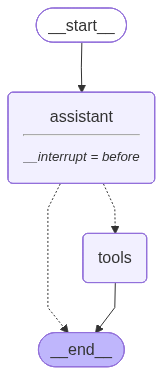

In [13]:
from IPython.display import Image, display

from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import MessagesState
from langgraph.graph import START, StateGraph
from langgraph.prebuilt import tools_condition, ToolNode

from langchain_core.messages import AIMessage, HumanMessage, SystemMessage

#define nodes
def assistant (state:MessagesState): 
    sys_msg=SystemMessage(content='You are a helpful assistant tasked with performing arithmetic on a set of inputs.')
    return {'messages':[llm_w_tools.invoke([sys_msg]+state['messages'])]}

builder=StateGraph(MessagesState)

builder.add_node('assistant', assistant)
builder.add_node('tools',ToolNode(tools_l))

builder.add_edge(START, 'assistant')
builder.add_conditional_edges(
    "assistant",
    tools_condition
)

memory = MemorySaver()
graph=builder.compile(interrupt_before=['assistant'], checkpointer=memory)

display(Image(graph.get_graph(xray=True).draw_mermaid_png()))

In [14]:
input_1 = {"messages": HumanMessage(content="minus 2 from 3")}

config = {"configurable": {"thread_id": "1"}}

for event in graph.stream(input_1, config, stream_mode="values"):
    event['messages'][-1].pretty_print()

================================ Human Message =================================

minus 2 from 3


In [19]:
state = graph.get_state(config)
state

StateSnapshot(values={'messages': [HumanMessage(content='minus 2 from 3', additional_kwargs={}, response_metadata={}, id='c6e28d3a-e9fb-4392-ba2b-4e5b553710f2'), HumanMessage(content='No, actually multiply 3 and 3!', additional_kwargs={}, response_metadata={}, id='332175f9-70e5-4dd0-bc88-f9b8fed5a74f')]}, next=('assistant',), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f159411-d25d-6faa-8001-98c2839b76a5'}}, metadata={'source': 'update', 'step': 1, 'parents': {}}, created_at='2026-05-26T20:26:02.196347+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f15940d-8b34-6c7c-8000-f30985d0ff10'}}, tasks=(PregelTask(id='974aad33-16b8-33a7-1777-9758921002d3', name='assistant', path=('__pregel_pull', 'assistant'), error=None, interrupts=(), state=None, result=None),), interrupts=())

In [7]:
state = graph.get_state(config)
state.next

('tools',)

In [17]:
graph.update_state(
    config,
    {"messages": [HumanMessage(content="No, actually multiply 3 and 3!")]},
)

{'configurable': {'thread_id': '1',
  'checkpoint_ns': '',
  'checkpoint_id': '1f159411-d25d-6faa-8001-98c2839b76a5'}}

In [23]:
new_state = graph.get_state(config).values
for m in new_state['messages']:
    m.pretty_print()

================================ Human Message =================================

minus 2 from 3
================================ Human Message =================================

No, actually multiply 3 and 3!
================================== Ai Message ==================================
Tool Calls:
  multiply (a94bb67a-d234-4156-bea2-06a7260bb7c8)
 Call ID: a94bb67a-d234-4156-bea2-06a7260bb7c8
  Args:
    a: 3
    b: 3
================================= Tool Message =================================
Name: multiply

9


In [24]:
for event in graph.stream(None, config, stream_mode="values"):
    event['messages'][-1].pretty_print()

================================= Tool Message =================================
Name: multiply

9


In [9]:
input_3 = {"messages": HumanMessage(content="divide 2 by 3")}
config = {"configurable": {"thread_id": "1"}}
events=graph.stream(input_3, config, stream_mode="values")
for event in events:
    event['messages'][-1].pretty_print()


================================ Human Message =================================

divide 2 by 3
================================== Ai Message ==================================
Tool Calls:
  divide (4157f8f6-f258-4e1f-a10b-70daa4dd15c5)
 Call ID: 4157f8f6-f258-4e1f-a10b-70daa4dd15c5
  Args:
    a: 2
    b: 3


In [10]:
for event in graph.stream(None, config, stream_mode="values"):
    event['messages'][-1].pretty_print()

================================== Ai Message ==================================
Tool Calls:
  divide (4157f8f6-f258-4e1f-a10b-70daa4dd15c5)
 Call ID: 4157f8f6-f258-4e1f-a10b-70daa4dd15c5
  Args:
    a: 2
    b: 3
================================= Tool Message =================================
Name: divide

0.6666666666666666


In [27]:
for m in graph.get_state(config).values['messages']:
    m.pretty_print()

================================ Human Message =================================

minus 2 from 3
================================ Human Message =================================

No, actually multiply 3 and 3!
================================== Ai Message ==================================
Tool Calls:
  multiply (a94bb67a-d234-4156-bea2-06a7260bb7c8)
 Call ID: a94bb67a-d234-4156-bea2-06a7260bb7c8
  Args:
    a: 3
    b: 3
================================= Tool Message =================================
Name: multiply

9


In [12]:
# Input
initial_input = {"messages": HumanMessage(content="Multiply 2 and 3")}

# Thread
thread = {"configurable": {"thread_id": "2"}}

# Run the graph until the first interruption
for event in graph.stream(initial_input, thread, stream_mode="values"):
    event['messages'][-1].pretty_print()

# Get user feedback
user_approval = input("Do you want to call the tool? (yes/no): ")

# Check approval
if user_approval.lower() == "yes":
    
    # If approved, continue the graph execution
    for event in graph.stream(None, thread, stream_mode="values"):
        event['messages'][-1].pretty_print()
        
else:
    print("Operation cancelled by user.")

================================ Human Message =================================

Multiply 2 and 3
================================== Ai Message ==================================
Tool Calls:
  multiply (4458e7fb-50dc-4d17-944a-420f95a584b0)
 Call ID: 4458e7fb-50dc-4d17-944a-420f95a584b0
  Args:
    a: 2
    b: 3


Do you want to call the tool? (yes/no):  yes


================================== Ai Message ==================================
Tool Calls:
  multiply (4458e7fb-50dc-4d17-944a-420f95a584b0)
 Call ID: 4458e7fb-50dc-4d17-944a-420f95a584b0
  Args:
    a: 2
    b: 3
================================= Tool Message =================================
Name: multiply

6


In [28]:
###add human input 

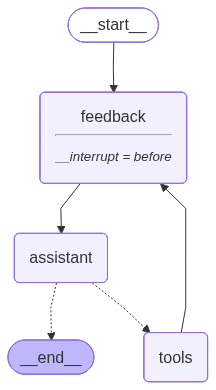

In [41]:
#define nodes
def assistant (state:MessagesState): 
    sys_msg=SystemMessage(content='You are a helpful assistant tasked with performing arithmetic on a set of inputs.')
    return {'messages':[llm_w_tools.invoke([sys_msg]+state['messages'])]}

def human_feedback(state: MessagesState): 
    pass

builder=StateGraph(MessagesState)

builder.add_node('assistant', assistant)
builder.add_node('feedback', human_feedback)
builder.add_node('tools',ToolNode(tools_l))

# Define edges: these determine the control flow
builder.add_edge(START, "feedback")
builder.add_edge("feedback", "assistant")
builder.add_conditional_edges(
    "assistant",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition,
)
builder.add_edge("tools", "feedback")

memory = MemorySaver()
graph = builder.compile(interrupt_before=["feedback"], checkpointer=memory)
display(Image(graph.get_graph().draw_mermaid_png()))

In [39]:
state=graph.get_state({"configurable": {"thread_id": "1"}})
state

StateSnapshot(values={}, next=(), config={'configurable': {'thread_id': '1'}}, metadata=None, created_at=None, parent_config=None, tasks=(), interrupts=())

In [42]:
# Input
initial_input = {"messages": "Multiply 2 and 3"}

# Thread
thread = {"configurable": {"thread_id": "1"}}

# Run the graph until the first interruption
for event in graph.stream(initial_input, thread, stream_mode="values"):
    event["messages"][-1].pretty_print()

# Get user input
user_input = input("Tell me how you want to update the state: ")

# We now update the state as if we are the human_feedback node
graph.update_state(thread, {"messages": user_input}, as_node="feedback")

# Continue the graph execution
for event in graph.stream(None, thread, stream_mode="values"):
    event["messages"][-1].pretty_print()

================================ Human Message =================================

Multiply 2 and 3


Tell me how you want to update the state:  devide 4 by 2


================================ Human Message =================================

devide 4 by 2
================================== Ai Message ==================================
Tool Calls:
  multiply (7510b88f-7071-471d-8fb1-e3a367b52ec2)
 Call ID: 7510b88f-7071-471d-8fb1-e3a367b52ec2
  Args:
    b: 3
    a: 2
  divide (6fc1d8ef-74f0-434d-8dd5-339085e750c3)
 Call ID: 6fc1d8ef-74f0-434d-8dd5-339085e750c3
  Args:
    a: 4
    b: 2
================================= Tool Message =================================
Name: divide

2.0


In [43]:
# Continue the graph execution
for event in graph.stream(None, thread, stream_mode="values"):
    event["messages"][-1].pretty_print()

================================= Tool Message =================================
Name: divide

2.0
================================== Ai Message ==================================

The product of 2 and 3 is 6. The division of 4 by 2 is 2.


#Time travel 

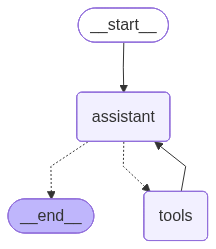

In [46]:
from IPython.display import Image, display

from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import MessagesState
from langgraph.graph import START, END, StateGraph
from langgraph.prebuilt import tools_condition, ToolNode

from langchain_core.messages import AIMessage, HumanMessage, SystemMessage


# Node
def assistant(state: MessagesState):
    # System message
   sys_msg = SystemMessage(content="You are a helpful assistant tasked with performing arithmetic on a set of inputs.")
   return {"messages": [llm_w_tools.invoke([sys_msg] + state["messages"])]}

# Graph
builder = StateGraph(MessagesState)

# Define nodes: these do the work
builder.add_node("assistant", assistant)
builder.add_node("tools", ToolNode(tools_l))

# Define edges: these determine the control flow
builder.add_edge(START, "assistant")
builder.add_conditional_edges(
    "assistant",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition,
)
builder.add_edge("tools", "assistant")

memory = MemorySaver()
graph = builder.compile(checkpointer=MemorySaver())

# Show
display(Image(graph.get_graph(xray=True).draw_mermaid_png()))

In [49]:
# Input
initial_input = {"messages": HumanMessage(content="Multiply 2 and 3")}

# Thread
config = {"configurable": {"thread_id": "1"}}

# Run the graph until the first interruption
# for event in graph.stream(initial_input, thread, stream_mode="values"):
#     event['messages'][-1].pretty_print()

output=graph.invoke(initial_input,config)
for m in output['messages'][-1:]:
    m.pretty_print()

================================== Ai Message ==================================

The answer is 6.


In [50]:
graph.get_state({'configurable': {'thread_id': '1'}})

StateSnapshot(values={'messages': [HumanMessage(content='Multiply 2 and 3', additional_kwargs={}, response_metadata={}, id='cd541214-737a-499a-b65b-dce98da9d770'), AIMessage(content='', additional_kwargs={'function_call': {'name': 'multiply', 'arguments': '{"a": 2, "b": 3}'}, '__gemini_function_call_thought_signatures__': {'73080680-71b6-461c-880c-5a7832c655e9': 'CvYBAQw51sea+nj2S3+PpnNhRiLyblPSdVkz397eUBKfxGxfKTKGJcgARc9dR27kk02raioAoCzOveCS7sAlqT4HGZwCPq3zBxVM4veMRgcepYX1A2NeGsCAqnwfSEwaoDUTlotO1RtPQDK5yjnOgs1GNBCjSUWfT4wdaZQJ56cgBvwXlR30OV9pcJcYGVvrSwwtjijwJQY8MWcMRBDT9yvAU6xqrOzCsz+zqoSztAd4h0LgutBDbutQHrUx7iEXQg8SkPgTMd0zdmfP6nMu2sgAg94+n4cIJLYIJWEk401nPQw4uAh/qaxD0HxfbYZzJluGiIKToVnl'}}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019e6654-5d91-72c2-8461-27c23fa11389-0', tool_calls=[{'name': 'multiply', 'args': {'a': 2, 'b': 3}, 'id': '73080680-71b6-461c-880c-5a7832c655e9', 'typ

In [51]:
all_states = [s for s in graph.get_state_history(thread)]

In [52]:
len(all_states)

7

In [58]:
for i in range(len(all_states)): 
    s=all_states[i]
    print(f'=====state#{i}========')
    for m in s.values['messages']:
        m.pretty_print()

=====state#0========
================================ Human Message =================================

Multiply 2 and 3
================================== Ai Message ==================================
Tool Calls:
  multiply (73080680-71b6-461c-880c-5a7832c655e9)
 Call ID: 73080680-71b6-461c-880c-5a7832c655e9
  Args:
    a: 2
    b: 3
================================= Tool Message =================================
Name: multiply

6
================================== Ai Message ==================================

The answer is 6.
=====state#1========
================================ Human Message =================================

Multiply 2 and 3
================================== Ai Message ==================================
Tool Calls:
  multiply (73080680-71b6-461c-880c-5a7832c655e9)
 Call ID: 73080680-71b6-461c-880c-5a7832c655e9
  Args:
    a: 2
    b: 3
================================= Tool Message =================================
Name: multiply

6
=====state#2========
==========

In [59]:
to_replay = all_states[-4]

In [62]:
to_replay.config

{'configurable': {'thread_id': '1',
  'checkpoint_ns': '',
  'checkpoint_id': '1f1594f5-3081-66ca-8002-6058542fd3f1'}}

In [63]:
for event in graph.stream(None, to_replay.config, stream_mode="values"):
    event['messages'][-1].pretty_print()

================================ Human Message =================================

Multiply 2 and 3
================================== Ai Message ==================================
Tool Calls:
  multiply (cc2292d8-fcd0-4e35-95ae-2d1836109b8b)
 Call ID: cc2292d8-fcd0-4e35-95ae-2d1836109b8b
  Args:
    a: 2
    b: 3
================================= Tool Message =================================
Name: multiply

6
================================== Ai Message ==================================

The answer is 6.


In [65]:
to_fork = all_states[-4]
to_fork.values["messages"]

[HumanMessage(content='Multiply 2 and 3', additional_kwargs={}, response_metadata={}, id='cd541214-737a-499a-b65b-dce98da9d770')]

In [66]:
to_fork.values["messages"][0].id

'cd541214-737a-499a-b65b-dce98da9d770'

In [67]:
to_fork.config

{'configurable': {'thread_id': '1',
  'checkpoint_ns': '',
  'checkpoint_id': '1f1594f5-3081-66ca-8002-6058542fd3f1'}}

In [68]:
to_fork

StateSnapshot(values={'messages': [HumanMessage(content='Multiply 2 and 3', additional_kwargs={}, response_metadata={}, id='cd541214-737a-499a-b65b-dce98da9d770')]}, next=('assistant',), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f1594f5-3081-66ca-8002-6058542fd3f1'}}, metadata={'source': 'loop', 'step': 2, 'parents': {}}, created_at='2026-05-26T22:07:45.552342+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f1594f5-307e-677c-8001-ff9eee9aab8a'}}, tasks=(PregelTask(id='92b03a65-10b5-7c68-c815-132d49d5bdd3', name='assistant', path=('__pregel_pull', 'assistant'), error=None, interrupts=(), state=None, result={'messages': [AIMessage(content='', additional_kwargs={'function_call': {'name': 'multiply', 'arguments': '{"a": 2, "b": 3}'}, '__gemini_function_call_thought_signatures__': {'73080680-71b6-461c-880c-5a7832c655e9': 'CvYBAQw51sea+nj2S3+PpnNhRiLyblPSdVkz397eUBKfxGxfKTKGJcgARc9dR27kk02raioAoCzOveCS

In [69]:
fork_config = graph.update_state(
    to_fork.config,
    {"messages": [HumanMessage(content='Multiply 5 and 3', 
                               id=to_fork.values["messages"][0].id)]},
)

In [70]:
fork_config

{'configurable': {'thread_id': '1',
  'checkpoint_ns': '',
  'checkpoint_id': '1f15955c-467e-6556-8003-9e6cfdcd4e65'}}

In [71]:
for event in graph.stream(None, fork_config, stream_mode="values"):
    event['messages'][-1].pretty_print()

================================ Human Message =================================

Multiply 5 and 3
================================== Ai Message ==================================
Tool Calls:
  multiply (40566cb4-9f7c-418a-b677-64cd5f0fec54)
 Call ID: 40566cb4-9f7c-418a-b677-64cd5f0fec54
  Args:
    b: 3
    a: 5
================================= Tool Message =================================
Name: multiply

15
================================== Ai Message ==================================

The product of 5 and 3 is 15.


In [72]:
all_states = [s for s in graph.get_state_history(thread)]

In [73]:
len(all_states)

15

In [75]:
for i in range(len(all_states)):
    s=all_states[i]
    print(f'====state-{i}====')
    for m in s.values['messages']:
        m.pretty_print()

====state-0====
================================ Human Message =================================

Multiply 5 and 3
================================== Ai Message ==================================
Tool Calls:
  multiply (40566cb4-9f7c-418a-b677-64cd5f0fec54)
 Call ID: 40566cb4-9f7c-418a-b677-64cd5f0fec54
  Args:
    b: 3
    a: 5
================================= Tool Message =================================
Name: multiply

15
================================== Ai Message ==================================

The product of 5 and 3 is 15.
====state-1====
================================ Human Message =================================

Multiply 5 and 3
================================== Ai Message ==================================
Tool Calls:
  multiply (40566cb4-9f7c-418a-b677-64cd5f0fec54)
 Call ID: 40566cb4-9f7c-418a-b677-64cd5f0fec54
  Args:
    b: 3
    a: 5
================================= Tool Message =================================
Name: multiply

15
====state-2====
==========